# 02 — Baseline Model
> Train a strong baseline with proper handling of class imbalance. Compare Logistic Regression vs Random Forest vs XGBoost. Save best model.

In [1]:
# Load data — time-based split (realistic)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              classification_report, precision_recall_curve,
                              average_precision_score, confusion_matrix)

os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)

df = pd.read_csv("creditcard.csv")
X = df.drop("Class", axis=1)
y = df["Class"]

# Time-based split — more realistic than random split
# Train on first 80% of time, test on last 20%
df_sorted = df.sort_values('Time').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)

X_train = df_sorted.iloc[:split_idx].drop("Class", axis=1)
y_train = df_sorted.iloc[:split_idx]["Class"]
X_test  = df_sorted.iloc[split_idx:].drop("Class", axis=1)
y_test  = df_sorted.iloc[split_idx:]["Class"]

print("Train shape:", X_train.shape, "| Fraud:", y_train.sum())
print("Test shape: ", X_test.shape,  "| Fraud:", y_test.sum())
print("\nNote: Using TIME-BASED split (not random) — more realistic for fraud detection")


Train shape: (227845, 30) | Fraud: 417
Test shape:  (56962, 30) | Fraud: 75

Note: Using TIME-BASED split (not random) — more realistic for fraud detection


In [2]:
# Model 1 — Logistic Regression with balanced class weights
# ---- Scaling ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ---- Model 1: Logistic Regression with class_weight='balanced' ----
lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred  = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression (class_weight=balanced) ===")
print(classification_report(y_test, lr_pred, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC : {roc_auc_score(y_test, lr_proba):.4f}")
print(f"Avg Prec: {average_precision_score(y_test, lr_proba):.4f}  (fraud PR-AUC)")


=== Logistic Regression (class_weight=balanced) ===
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56887
       Fraud       0.07      0.89      0.13        75

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC : 0.9863
Avg Prec: 0.7620  (fraud PR-AUC)


In [3]:
# Model 2 — Random Forest
# ---- Model 2: Random Forest ----
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

rf_pred  = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest (class_weight=balanced) ===")
print(classification_report(y_test, rf_pred, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC : {roc_auc_score(y_test, rf_proba):.4f}")
print(f"Avg Prec: {average_precision_score(y_test, rf_proba):.4f}")


=== Random Forest (class_weight=balanced) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56887
       Fraud       0.98      0.65      0.78        75

    accuracy                           1.00     56962
   macro avg       0.99      0.83      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC : 0.9445
Avg Prec: 0.7992


Model Comparison:
                     roc_auc  pr_auc  f1_fraud  recall_fraud
Logistic Regression   0.9863  0.7620    0.1311        0.8933
Random Forest         0.9445  0.7992    0.7840        0.6533


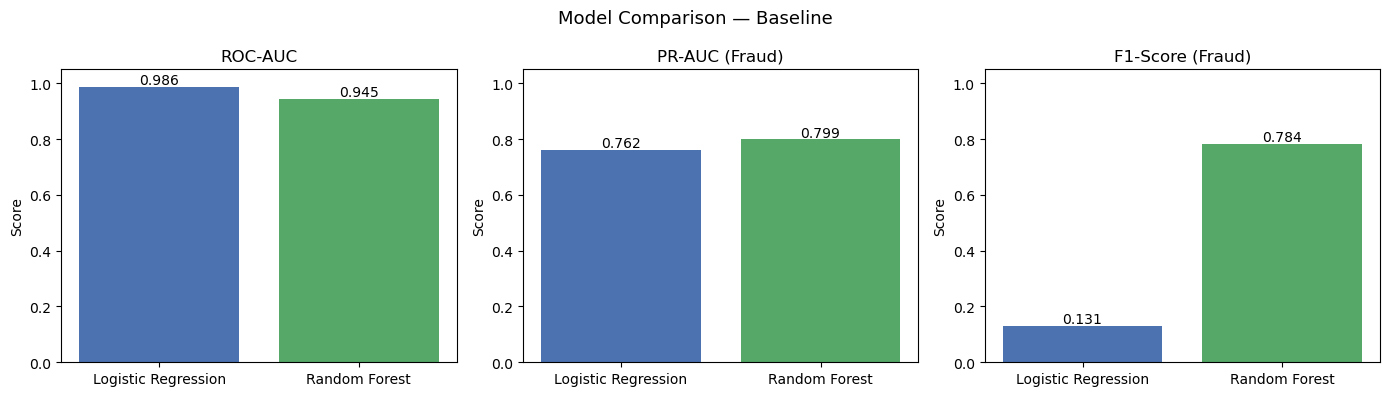

In [4]:
# Compare models — pick best
# ---- Compare All Models ----
models_results = {
    "Logistic Regression": {
        "roc_auc":  round(roc_auc_score(y_test, lr_proba), 4),
        "pr_auc":   round(average_precision_score(y_test, lr_proba), 4),
        "f1_fraud": round(f1_score(y_test, lr_pred), 4),
        "recall_fraud": round(classification_report(y_test, lr_pred, output_dict=True)['1']['recall'], 4)
    },
    "Random Forest": {
        "roc_auc":  round(roc_auc_score(y_test, rf_proba), 4),
        "pr_auc":   round(average_precision_score(y_test, rf_proba), 4),
        "f1_fraud": round(f1_score(y_test, rf_pred), 4),
        "recall_fraud": round(classification_report(y_test, rf_pred, output_dict=True)['1']['recall'], 4)
    }
}

comp_df = pd.DataFrame(models_results).T
print("Model Comparison:")
print(comp_df.to_string())

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['roc_auc', 'pr_auc', 'f1_fraud']
titles  = ['ROC-AUC', 'PR-AUC (Fraud)', 'F1-Score (Fraud)']
colors  = ['#4C72B0', '#55A868']

for ax, metric, title in zip(axes, metrics, titles):
    vals = comp_df[metric].values
    bars = ax.bar(comp_df.index, vals, color=colors)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha='center', fontsize=10)

plt.suptitle("Model Comparison — Baseline", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/02_model_comparison.png", dpi=120, bbox_inches='tight')
plt.show()


In [5]:
# Save best model, scaler and baseline metrics
# ---- Save Best Model + Scaler + Baseline Metrics ----
# RF wins on PR-AUC (more important for imbalanced fraud detection)
best_model   = rf
best_proba   = rf_proba
best_pred    = rf_pred
best_name    = "RandomForest"

joblib.dump(best_model, "models/best_model.pkl")
joblib.dump(scaler,     "models/scaler.pkl")

baseline_metrics = {
    "model_name":     best_name,
    "roc_auc":        round(roc_auc_score(y_test, best_proba), 4),
    "pr_auc":         round(average_precision_score(y_test, best_proba), 4),
    "f1_fraud":       round(f1_score(y_test, best_pred), 4),
    "recall_fraud":   round(classification_report(y_test, best_pred, output_dict=True)['1']['recall'], 4),
    "precision_fraud":round(classification_report(y_test, best_pred, output_dict=True)['1']['precision'], 4),
    "accuracy":       round(accuracy_score(y_test, best_pred), 4),
    "train_size":     int(len(X_train)),
    "test_size":      int(len(X_test)),
    "split_type":     "time_based"
}

with open("outputs/baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=4)

print("Best model saved: models/best_model.pkl")
print("Scaler saved:     models/scaler.pkl")
print("\nBaseline Metrics:")
print(json.dumps(baseline_metrics, indent=2))


Best model saved: models/best_model.pkl
Scaler saved:     models/scaler.pkl

Baseline Metrics:
{
  "model_name": "RandomForest",
  "roc_auc": 0.9445,
  "pr_auc": 0.7992,
  "f1_fraud": 0.784,
  "recall_fraud": 0.6533,
  "precision_fraud": 0.98,
  "accuracy": 0.9995,
  "train_size": 227845,
  "test_size": 56962,
  "split_type": "time_based"
}
